<a href="https://colab.research.google.com/github/raqueldias/ML4Bio/blob/main/Week_03_nb2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Linear Regressor for Proteomics

In this notebook, we will pivot from predicting a binary categorical outcome (classification) to predicting a **continuous numeric label**: the number of days remaining before the onset of labor (`Days before Labor`).

### Objectives
1. **Understand Continuous Targets:** Learn how regression differs structurally from classification workflows.
2. **Defeat Longitudinal Data Leakage (Patient Groups):** Map patient IDs to ensure a single patient's longitudinal samples never span between our Train and Validation splits.
3. **Build an L1-Regularized Regressor:** Fit a Lasso Regression model manually from scratch to prevent overfitting in a high-dimensional space ($p \approx 1,300$).
4. **Evaluate with Continuous Error Metrics:** Compute Mean Absolute Error (MAE), Mean Squared Error (MSE), and $R^2$.
5. **Plot Predicted vs. Actual Outcomes:** Generate a diagnostic scatter plot with a trendline.
6. **Extract Regression Signatures:** Interpret linear regression coefficients to identify candidate biomarkers indicating proximity to labor.

### This Dataset
This dataset, derived from high-dimensional multi-omic characterizations of pregnancy timelines, presents a challenge where the objective is to predict a continuous temporal label representing the exact number of days remaining before a patient goes into labor. Spanning independent training and validation cohorts, the data tracks individual patients longitudinally across multiple gestational weeks, capturing the dynamic molecular shifts leading up to childbirth. The Olink proximity extension assay panel isolates over 1,300 unique plasma protein biomarkers across blood draw samples. Because individuals were sampled repeatedly over time, this cohort serves as an ideal resource for learning regression analysis, multi-omic dimensionality reduction, and the vital implementation of group-based data splits to eliminate longitudinal autocorrelation and structural data leakage.


Reference: https://www.science.org/doi/10.1126/scitranslmed.abd9898

Original data source: https://datadryad.org/dataset/doi:10.5061/dryad.stqjq2c7d

In [ ]:
# ==========================================
# Download and Unzip Data
# ==========================================
# We use curl to pull the open-access multi-omic dataset directly from Data Dryad.
print("Downloading dataset from Data Dryad...")
!curl -L -o data.zip https://github.com/raqueldias/ML4Bio/raw/refs/heads/main/data.zip
print("Unzipping files into the local runtime environment...")
!unzip -q data.zip
print("Done! Files extracted.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 18.9M  100 18.9M    0     0  13.7M      0  0:00:01  0:00:01 --:--:-- 29.0M
Unzipping files into the local runtime environment...
Done! Files extracted.


In [ ]:
# ==========================================
# Load Datasets from the Local Runtime
# ==========================================
import pandas as pd
import numpy as np

# Load our Discovery/Training Data
X_train_raw = pd.read_csv("Onset of Labor/Training/Proteomics.csv", index_col=0)
y_train_raw = pd.read_csv("Onset of Labor/Training/DOS.csv", index_col=0)
patient_ids = pd.read_csv("Onset of Labor/Training/ID.csv", index_col=0)

# Load our External Validation/Independent Testing Data
X_test_raw = pd.read_csv("Onset of Labor/Validation/Proteomics_validation.csv", index_col=0)
y_test_raw = pd.read_csv("Onset of Labor/Validation/DOS_validation.csv", index_col=0)

print("--- Data Matrices Loaded Successfully ---")
print(f"Training Features: {X_train_raw.shape[1]} | Training Samples: {X_train_raw.shape[0]}")
print(f"Independent Testing Features: {X_test_raw.shape[1]} | Testing Samples: {X_test_raw.shape[0]}")

--- Data Matrices Loaded Successfully ---
Training Features: 1317 | Training Samples: 150
Independent Testing Features: 1317 | Testing Samples: 21


## Group-Based Splitting (Mitigating Data Leakage)

Our training set contains 150 samples tracking 53 unique individual patients. Because each patient donated blood samples at multiple gestational timepoints, treating every row as independent would lead to **Data Leakage**. If samples from Patient X end up in both our training split and internal validation split, our model will memorize individual baseline traits instead of learning generalized timelines of labor onset.

**The Solution:** We will extract the unique list of `Patient IDs`, split those *patients* into an 80/20 division, and then use those patient groupings to pull the corresponding sample rows into our clean `X_train` and `X_val` slices.

In [ ]:
# ==========================================
# Group-Based Splitting (Mitigating Data Leakage)
# ==========================================
from sklearn.model_selection import train_test_split

# Drop columns containing missing NaN values and align features across cohorts
X_train_clean = X_train_raw.dropna(axis=1)
X_test_clean = X_test_raw.dropna(axis=1)
shared_proteins = X_train_clean.columns.intersection(X_test_clean.columns)

X_train_shared = X_train_clean[shared_proteins]
X_test_shared = X_test_clean[shared_proteins]

# Extract the unique list of individual patient IDs directly from the DataFrame index
unique_patients = X_train_shared.index.unique()

# Split the unique PATIENTS themselves: 90% for training, 10% for validation
train_patients, val_patients = train_test_split(unique_patients, test_size=0.10, random_state=772026)

# Slice out our matrices ensuring no patient overlap by directly selecting rows by index labels
X_train = X_train_shared.loc[train_patients]
y_train = y_train_raw.loc[train_patients].values.ravel()

X_val = X_train_shared.loc[val_patients]
y_val = y_train_raw.loc[val_patients].values.ravel()

# Align y_test to match only the available samples in X_test
X_test = X_test_shared
y_test = y_test_raw.loc[X_test.index].values.ravel()
# -----------------------------------------------------------------------

print(f"Training set: {X_train.shape[0]} samples (from {len(train_patients)} unique patients)")
print(f"Internal Validation set: {X_val.shape[0]} samples (from {len(val_patients)} unique patients)")
print(f"Independent Test set: {X_test.shape[0]} samples (Aligned labels: {y_test.shape[0]})")

Training set: 135 samples (from 135 unique patients)
Internal Validation set: 15 samples (from 15 unique patients)
Independent Test set: 21 samples (Aligned labels: 21)


## Scaling & Linear Regression Fitting

To handle the high-dimensional feature space ($p \approx 1,300$), we must use regularization. We will train a **Lasso Regression model**. Lasso uses an **L1 penalty** which functions identically to the L1 penalty (alpha) in our Logistic Regression classifier: it penalizes the absolute size of coefficients, driving non-essential feature weights to exactly zero.

Remember our data handling standards: we fit our `StandardScaler` **exclusively on the training data** to avoid leaking global summary metrics.

In [ ]:
# ==========================================
# Standardization & Model Training
# ==========================================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

# 1. Initialize and fit the scaler strictly on the training partition
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 2. Fit the Regressor Equivalent of our L1 Classifier
# alpha plays the role of 1/C (smaller alpha = less regularization, larger alpha = more sparsity)
model = Lasso(alpha=2, random_state=772026, max_iter=5000)
model.fit(X_train_scaled, y_train)

print("Regression model trained successfully without data leakage.")

Regression model trained successfully without data leakage.


## Regression Evaluation Metrics & Diagnostic Plots

Because our label is continuous, we do not evaluate with accuracy or confusion matrices. Instead, we track how far off our numeric predictions are using:
* **Mean Absolute Error (MAE):** The average absolute distance between predicted days and actual days before labor.
* **Mean Squared Error (MSE):** Penalizes larger errors more heavily by squaring the distances.
* **R-squared ($R^2$):** The proportion of variance in our timeline explained by the protein features.

We will then generate a **Predicted vs. Actual Scatter Plot** along with an identity line ($y = x$) to see how tightly our predictions cluster around perfect accuracy.

=== REGRESSION PERFORMANCE SUMMARY ===


,MAE (Days),MSE,R-squared
Train Set,7.58,97.77,0.90
Internal Validation,15.00,259.52,0.73
Independent Test Set,12.45,227.09,0.69


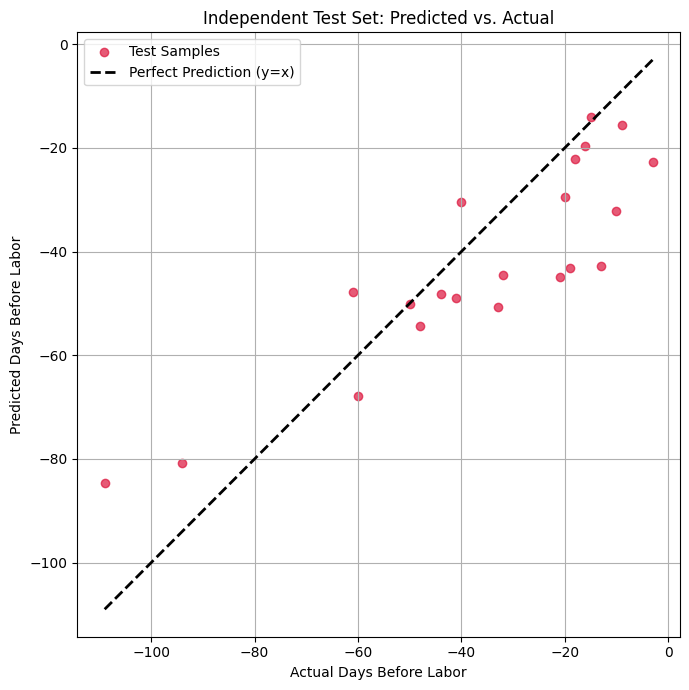

In [ ]:
# ==========================================
# Metrics Calculation & Visualization
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

datasets = {
    "Train Set": (X_train_scaled, y_train),
    "Internal Validation": (X_val_scaled, y_val),
    "Independent Test Set": (X_test_scaled, y_test)
}

metrics_summary = {}

# Compute Metrics
for name, (X_group, y_group) in datasets.items():
    y_pred = model.predict(X_group)
    metrics_summary[name] = {
        "MAE (Days)": mean_absolute_error(y_group, y_pred),
        "MSE": mean_squared_error(y_group, y_pred),
        "R-squared": r2_score(y_group, y_pred)
    }

# Display Performance Table
df_metrics = pd.DataFrame(metrics_summary).T
print("=== REGRESSION PERFORMANCE SUMMARY ===")
display(df_metrics.round(2))

# Plot Predicted vs. Actual for the Independent Test Set
y_test_pred = model.predict(X_test_scaled)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_test_pred, color='crimson', alpha=0.7, label='Test Samples')
# Draw a perfect prediction trendline
max_val = max(max(y_test), max(y_test_pred))
min_val = min(min(y_test), min(y_test_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction (y=x)')

plt.xlabel('Actual Days Before Labor')
plt.ylabel('Predicted Days Before Labor')
plt.title('Independent Test Set: Predicted vs. Actual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Extracting Biomarker Signatures for Onset of Labor

Because we standardized our protein measurements prior to model fitting, we can extract and evaluate our linear coefficients to see exactly which proteins are driving the model's timeline calculations.

### Understanding Continuous Linear Coefficients:
* **Positive Coefficients:** Higher expression of this protein indicates **more days remaining before labor** (i.e., the pregnancy is stable and not immediate).
* **Negative Coefficients:** Higher expression of this protein means a reduction in the target value, indicating the patient is **closer to labor**. These are your candidate biomarkers for imminent labor onset!

In [ ]:
# ==========================================
# Extracting Regression Coefficients
# ==========================================
coefficients = model.coef_

coef_df = pd.DataFrame({
    'Protein Biomarker': X_train.columns,
    'Regression Coefficient': coefficients
})

# Filter out proteins eliminated by the L1 Lasso penalty
active_biomarkers = coef_df[coef_df['Regression Coefficient'] != 0].sort_values(by='Regression Coefficient', ascending=False)

print(f"Total active predictive features selected by Lasso: {len(active_biomarkers)} out of {X_train.shape[1]}")
print("\nTop 5 Proteins Associated with a LONGER Time to Labor (Positive Weights):")
display(active_biomarkers.head(5))

print("\nTop 5 Proteins Associated with IMMINENT Labor Onset (Negative Weights):")
display(active_biomarkers.tail(5))

Total active predictive features selected by Lasso: 37 out of 1317

Top 5 Proteins Associated with a LONGER Time to Labor (Positive Weights):


,Protein Biomarker,Regression Coefficient
793,IL.1.R4,5.440975
223,Siglec.6,4.427233
229,Activin.A,4.306938
1316,PLXB2,4.081891
838,SLPI,3.282301



Top 5 Proteins Associated with IMMINENT Labor Onset (Negative Weights):


,Protein Biomarker,Regression Coefficient
959,HCG,-1.687655
673,sTie.2,-1.976959
901,SLIK5,-2.015895
501,Antithrombin.III,-2.769141
154,Angiopoietin.2,-3.929453
